In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from typing import Dict, Tuple

# --- observable scalars (rely on your existing implementations) ---
def R_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    return galaxy_lens_distance_ratio(float(zl), float(zs), **cosmo)

def Ddt_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    return time_delay_distance(float(zl), float(zs), **cosmo)

def beta_scalar(zl: float, zs1: float, zs2: float, cosmo: Dict) -> float:
    return double_source_beta(float(zl), float(zs1), float(zs2), **cosmo)

# --- prepare cosmology dict for a chosen model ---
def _prepare_cosmo(model: str, H0: float, Om0: float, Ok0: float,
                   w: float = None, w0: float = None, wa: float = None, alpha: float = None) -> Dict:
    c = dict(H0=H0, omega_m=Om0, omega_k=Ok0, model=model)
    if model == 'constw':
        c['w'] = float(w)
    elif model == 'cpl':
        c['w0'] = float(w0)
        c['wa'] = float(wa)
    elif model == 'wphi':
        c['w0']   = float(w0)
        c['alpha'] = float(alpha)
    else:
        raise ValueError("model must be one of {'constw','cpl','wphi'}")
    return c

# --- parameter ranges (as requested) ---
PRANGE = {
    'constw': {
        'Om0':  (0.0, 1.0),
        'Ok0':  (-0.5, 0.5),
        'w':    (-2.0, 0.0),
        'H0':   (40.0, 100.0),  # free slider; default 70
    },
    'cpl': {
        'Om0':  (0.0, 1.0),
        'Ok0':  (-0.5, 0.5),
        'w0':   (-2.0, 0.0),
        'wa':   (-4.0, 1.0),
        'H0':   (40.0, 100.0),
    },
    'wphi': {
        'Om0':  (0.0, 1.0),
        'Ok0':  (-0.5, 0.5),
        'w0':   (-2.0, 0.0),
        'alpha':(1.0, 2.0),
        'H0':   (40.0, 100.0),
    }
}

# --- robust finite-diff step per parameter (uses absolute step inside allowed range) ---
def _fd_step(model: str, p: str, val: float,
             eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> Tuple[float, float]:
    lo, hi = PRANGE[model].get(p, (None, None))
    # prefer absolute steps for parameters that can be ~0 or sign-changing
    if p in ('Ok0', 'w', 'w0', 'wa'):
        dp = max(eps_abs, 1e-4)
    elif p == 'Om0':
        dp = max(eps_abs, 1e-4)
    elif p == 'alpha':
        base = max(val, 1e-6)
        dp = max(eps_abs, base * eps_rel)
    elif p == 'H0':
        dp = max(eps_abs, 1e-3*max(1.0, val))
    else:
        dp = max(eps_abs, abs(val)*eps_rel)
    p_minus, p_plus = val - dp, val + dp
    # clip to allowed range when known
    if lo is not None and hi is not None:
        p_minus = np.clip(p_minus, lo, hi)
        p_plus  = np.clip(p_plus,  lo, hi)
        # ensure not equal
        if np.isclose(p_minus, p_plus):
            p_minus = max(lo, val - 2*dp)
            p_plus  = min(hi, val + 2*dp)
    return float(p_minus), float(p_plus)

# --- generic derivative of ln observable wrt parameter p ---
def _dln_obs_dp(obs_fn, zl, zs_or_tuple, cosmo_in: Dict, p: str,
                eps_rel=1e-5, eps_abs=1e-5) -> float:
    # base
    if obs_fn is beta_scalar:
        zl_f = float(zl)
        zs1_f, zs2_f = float(zs_or_tuple[0]), float(zs_or_tuple[1])
        base = obs_fn(zl_f, zs1_f, zs2_f, cosmo_in)
    else:
        zl_f = float(zl)
        zs_f = float(zs_or_tuple)
        base = obs_fn(zl_f, zs_f, cosmo_in)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    model = cosmo_in.get('model', 'cpl')
    # value for p may be stored under different keys in backend:
    # unify names here: H0, Om0->omega_m, Ok0->omega_k, and EOS params as-is
    # build two copies and adjust the specific key
    def _apply_param(d: Dict, key: str, val: float):
        dd = dict(d)
        if key == 'H0':         dd['H0'] = val
        elif key == 'Om0':      dd['omega_m'] = val
        elif key == 'Ok0':      dd['omega_k'] = val
        else:                   dd[key] = val
        return dd

    # current value (guess from dict)
    cur = (cosmo_in['H0'] if p=='H0' else
           cosmo_in['omega_m'] if p=='Om0' else
           cosmo_in['omega_k'] if p=='Ok0' else
           cosmo_in.get(p, None))
    if cur is None:
        return np.nan
    p_minus, p_plus = _fd_step(model, p, float(cur), eps_rel=eps_rel, eps_abs=eps_abs)
    c_m = _apply_param(cosmo_in, p, p_minus)
    c_p = _apply_param(cosmo_in, p, p_plus)

    if obs_fn is beta_scalar:
        bm = obs_fn(zl_f, zs1_f, zs2_f, c_m)
        bp = obs_fn(zl_f, zs1_f, zs2_f, c_p)
    else:
        bm = obs_fn(zl_f, zs_f, c_m)
        bp = obs_fn(zl_f, zs_f, c_p)

    if (bm <= 0) or (bp <= 0) or (not np.isfinite(bm)) or (not np.isfinite(bp)):
        return np.nan

    return float((np.log(bp) - np.log(bm)) / (p_plus - p_minus))

# convenience wrappers
def dlnR_dp(zl, zs, cosmo, p, **kw):     return _dln_obs_dp(R_scalar,   zl, zs,       cosmo, p, **kw)
def dlnDdt_dp(zl, zs, cosmo, p, **kw):   return _dln_obs_dp(Ddt_scalar, zl, zs,       cosmo, p, **kw)
def dlnbeta_dp(zl, zs1, zs2, cosmo, p, **kw): return _dln_obs_dp(beta_scalar, zl, (zs1, zs2), cosmo, p, **kw)


In [2]:

from dataclasses import dataclass
from typing import Optional, Literal
from astropy import units as u
from astropy import constants as const
import numpy as np
try:
    from scipy.integrate import quad
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

C_KMS = const.c.to(u.km/u.s).value

ModelT = Literal['constw', 'cpl', 'wphi']

@dataclass
class CosmoParams:
    H0: float = 70.0            # [km/s/Mpc]
    Om0: float = 0.3            # Ω_m
    Ok0: float = 0.0            # Ω_k
    Or0: float = 0.0            # Ω_r (通常可忽略)
    # ---- choose dark-energy model via `model` ----
    model: ModelT = 'cpl'       # 'constw' | 'cpl' | 'wphi'
    # const-w:
    w: Optional[float] = None
    # CPL: w(a)=w0+wa(1-a)
    w0: float = -1.0
    wa: float = 0.0
    # w_phi: w(z) = -1 + (1+w0) exp(-alpha z)
    alpha: Optional[float] = None

    def Ode0(self) -> float:
        return 1.0 - self.Om0 - self.Ok0 - self.Or0

def _rho_de_factor(z: float, cp: CosmoParams) -> float:
    """
    ρ_DE(z)/ρ_DE(0) for the chosen dark-energy model.
    - constw: (1+z)^{3(1+w)}
    - cpl:    (1+z)^{3(1+w0+wa)} * exp[-3 wa z/(1+z)]
    - wphi:   F(z) per your definition using exp1 (E1).
              F(z) = exp{ 3 e^{alpha} (1+w0) [E1(alpha) - E1(alpha(1+z))] }
    """
    m = cp.model
    if m == 'constw':
        w = cp.w if cp.w is not None else -1.0
        return (1.0 + z)**(3.0 * (1.0 + w))

    if m == 'cpl':
        return (1.0 + z)**(3.0 * (1.0 + cp.w0 + cp.wa)) * np.exp(-3.0 * cp.wa * z / (1.0 + z))

    if m == 'wphi':
        if cp.alpha is None:
            raise ValueError("For model='wphi', please set CosmoParams.alpha (and w0).")
        A = 3.0 * np.exp(cp.alpha) * (1.0 + cp.w0)
        return np.exp(A * (exp1(cp.alpha) - exp1(cp.alpha * (1.0 + z))))

    raise ValueError(f"Unknown DE model: {m}")

def Ez(z: float, cp: CosmoParams) -> float:
    """E(z) = H(z)/H0 with chosen dark-energy model."""
    de = cp.Ode0() * _rho_de_factor(z, cp)
    return np.sqrt(cp.Om0*(1.0+z)**3 + cp.Or0*(1.0+z)**4 + cp.Ok0*(1.0+z)**2 + de)

def _chi_quad(z: float, cp: CosmoParams) -> float:
    """无量纲共动径向距离 χ(z) = ∫_0^z dz'/E(z')."""
    if _HAS_SCIPY:
        val, _ = quad(lambda zp: 1.0 / Ez(zp, cp), 0.0, float(z), epsrel=1e-8, epsabs=0.0, limit=256)
        return val
    zgrid = np.linspace(0.0, float(z), 4097)
    return np.trapz(1.0 / np.vectorize(Ez)(zgrid, cp), zgrid)

def _Sk(x: float, Ok0: float) -> float:
    """曲率函数 S_k(x)，x = √|Ω_k| χ。"""
    if abs(Ok0) < 1e-12: return x
    return np.sinh(x) if Ok0 > 0.0 else np.sin(x)

def D_M(z: float, cp: CosmoParams) -> float:
    """横向共动距离 D_M(z) [Mpc]."""
    chi = _chi_quad(z, cp)
    if abs(cp.Ok0) < 1e-12:
        return (C_KMS / cp.H0) * chi
    sqrtOk = np.sqrt(abs(cp.Ok0))
    return (C_KMS / cp.H0) * _Sk(sqrtOk * chi, cp.Ok0) / sqrtOk

def D_A(z: float, cp: CosmoParams) -> float:
    """角径距 D_A(0→z) [Mpc]."""
    return D_M(z, cp) / (1.0 + z)

def D_A12(z1: float, z2: float, cp: CosmoParams) -> float:
    """两红移间角径距 D_A(z1→z2) [Mpc], 需 z2>z1。"""
    if not (z2 > z1):
        raise ValueError("Require z2 > z1 for D_A12.")
    chi1 = _chi_quad(z1, cp); chi2 = _chi_quad(z2, cp)
    dchi = chi2 - chi1
    if abs(cp.Ok0) < 1e-12:
        DM12 = (C_KMS / cp.H0) * dchi
    else:
        sqrtOk = np.sqrt(abs(cp.Ok0))
        DM12 = (C_KMS / cp.H0) * _Sk(sqrtOk * dchi, cp.Ok0) / sqrtOk
    return DM12 / (1.0 + z2)

# ---- wrappers (unchanged signatures + new args: model, alpha) ----
def Dl(zl: float, cp: CosmoParams) -> float: return D_A(zl, cp)
def Ds(zs: float, cp: CosmoParams) -> float: return D_A(zs, cp)
def Dls(zl: float, zs: float, cp: CosmoParams) -> float: return D_A12(zl, zs, cp)

# =========================
# 1) Galaxy–galaxy lens: R = Ds / Dls
# =========================
def galaxy_lens_distance_ratio(zl: float, zs: float, *,
                               H0: float, omega_m: float,
                               omega_k: float = 0.0, omega_r: float = 0.0,
                               w: Optional[float] = None,
                               w0: float = -1.0, wa: float = 0.0,
                               model: ModelT = 'cpl', alpha: Optional[float] = None) -> float:
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    return Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 2) Time-delay: D_dt = (1+zl) Dl Ds / Dls
# =========================
def time_delay_distance(zl: float, zs: float, *,
                        H0: float, omega_m: float,
                        omega_k: float = 0.0, omega_r: float = 0.0,
                        w: Optional[float] = None,
                        w0: float = -1.0, wa: float = 0.0,
                        model: ModelT = 'cpl', alpha: Optional[float] = None) -> float:
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    return (1.0 + zl) * Dl(zl, cp) * Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 3) DSP: β = (D_ls2/D_s2) / (D_ls1/D_s1)
# =========================
def double_source_beta(zl: float, zs1: float, zs2: float, *,
                       H0: float, omega_m: float,
                       omega_k: float = 0.0, omega_r: float = 0.0,
                       w: Optional[float] = None,
                       w0: float = -1.0, wa: float = 0.0,
                       model: ModelT = 'cpl', alpha: Optional[float] = None) -> float:
    if not (zl < zs1 < zs2):
        raise ValueError("Require zl < zs1 < zs2 for double-source lensing.")
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    num = Dls(zl, zs2, cp) / Ds(zs2, cp)
    den = Dls(zl, zs1, cp) / Ds(zs1, cp)
    return num / den

# -------- vectorized shells: add (model, alpha) pass-through --------
def galaxy_lens_distance_ratio_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0,
    model: ModelT = 'cpl', alpha: Optional[float] = None
):
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = float(zl_i), float(zs_i)
        o[...] = np.nan if zs_f <= zl_f else Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
    return out

def time_delay_distance_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0,
    model: ModelT = 'cpl', alpha: Optional[float] = None
):
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = float(zl_i), float(zs_i)
        o[...] = np.nan if zs_f <= zl_f else (1.0 + zl_f) * Dl(zl_f, cp) * Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
    return out

def double_source_beta_vec(
    zl, zs1, zs2, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0,
    model: ModelT = 'cpl', alpha: Optional[float] = None
):
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    zlA, z1A, z2A = np.broadcast_arrays(np.asarray(zl, float),
                                        np.asarray(zs1, float),
                                        np.asarray(zs2, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, z1A, z2A, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['readonly'], ['writeonly']])
    for zl_i, z1_i, z2_i, o in it:
        zl_f, z1_f, z2_f = float(zl_i), float(z1_i), float(z2_i)
        if not (zl_f < z1_f < z2_f):
            o[...] = np.nan
        else:
            num = Dls(zl_f, z2_f, cp) / Ds(z2_f, cp)
            den = Dls(zl_f, z1_f, cp) / Ds(z1_f, cp)
            o[...] = num / den
    return out


<>:63: SyntaxWarning: invalid escape sequence '\O'
<>:63: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_9788/4193595289.py:63: SyntaxWarning: invalid escape sequence '\O'
  label=r"$\Omega_m$",    # optional
/tmp/ipykernel_9788/4193595289.py:269: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])


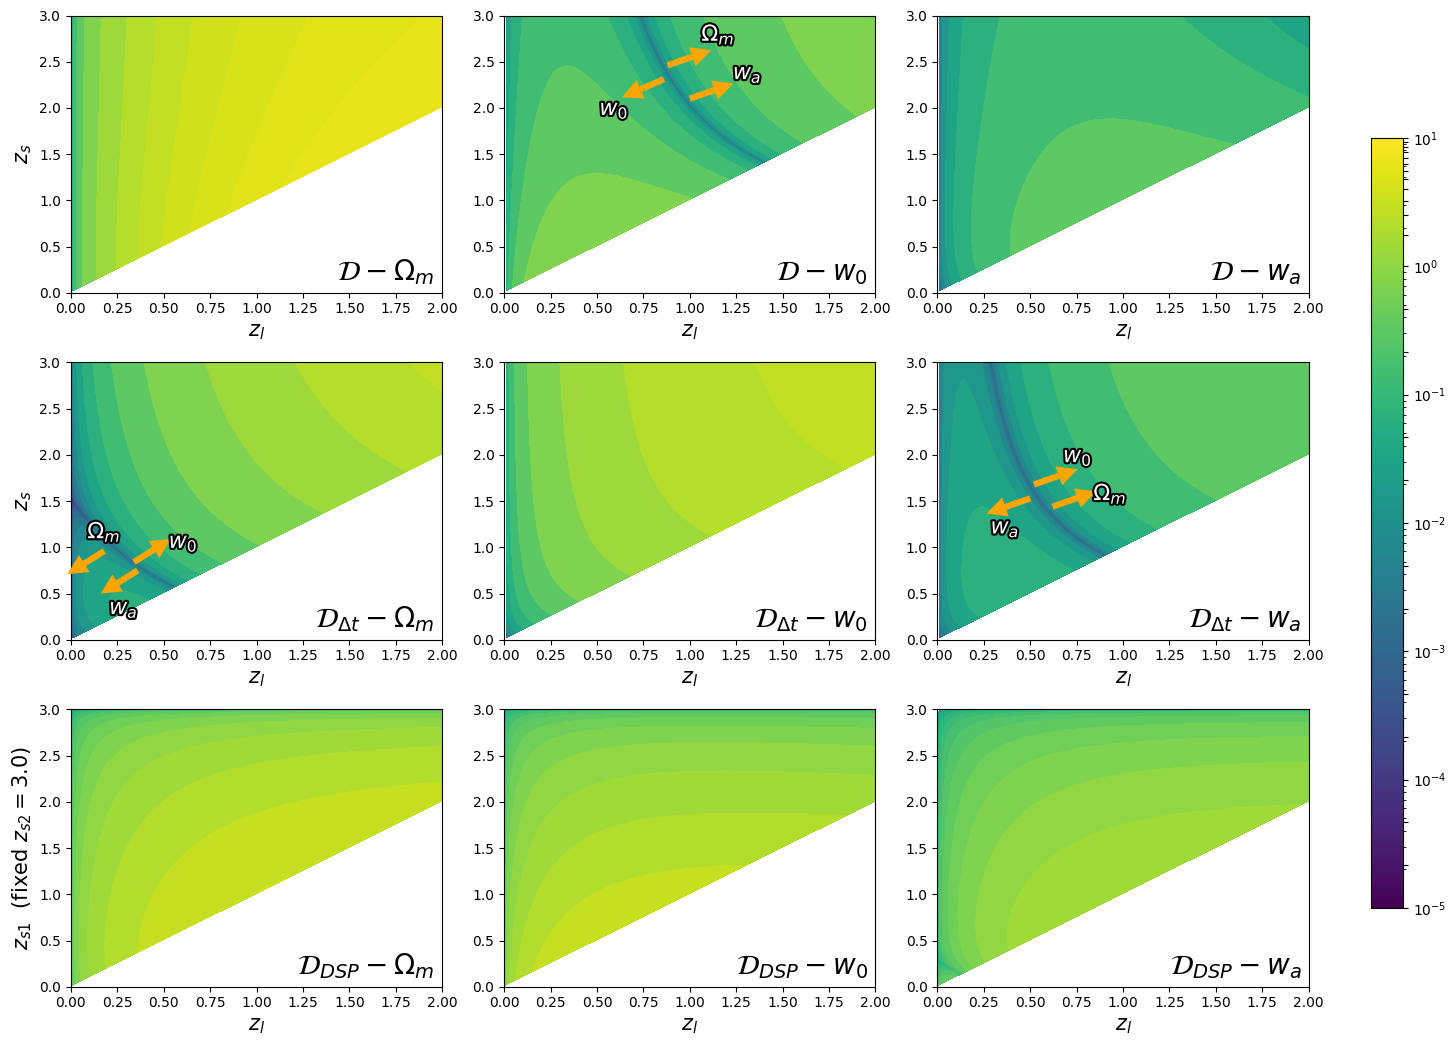

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
import matplotlib.patheffects as pe
from scipy.special import gamma as Gamma, exp1  # E1(x)


def plot_sensitivity_contours_3x4(
    cosmo_cpl,
    *,  # grids
    zl_min=0.0, zl_max=2.0, zl_step=0.1,
    zs_min=0.0, zs_max=3.0, zs_step=0.1,
    zs2_fixed=2.0, zs1_step=0.1, eps=1e-6,
    sigma_frac=0.1,
    cmap="viridis",
    figsize=(16, 11),
    outputname="contours_all_3x4.png",
    wphi_alpha=1.2,
    # 绘图底限（避免 LogNorm 对 0 置空）
    tiny_floor=1e-12,
    # 若整张图都低于 vmin，是否自动降低 vmin
    auto_relax_vmin=True
):
    # --- CPL cosmology for the first 3 columns ---
    cosmo_cpl_use = dict(
        H0=cosmo_cpl.get("H0", 70.0),
        omega_m=cosmo_cpl.get("omega_m", 0.3),
        omega_k=cosmo_cpl.get("omega_k", 0.0),
        w0=cosmo_cpl.get("w0", -0.95),  # 你已确保 != -1
        wa=cosmo_cpl.get("wa", 0.0)
    )
    cosmo_cpl_use.pop("w", None)


    params       = ["omega_m", "w0", "wa"]
    cosmo_percol = [cosmo_cpl_use, cosmo_cpl_use, cosmo_cpl_use]

    param_tex1 = [r"$\mathcal{D}-\Omega_m$", r"$\mathcal{D}-w_0$",
                  r"$\mathcal{D}-w_a$"]
    param_tex2 = [r"$\mathcal{D}_{\Delta t}-\Omega_m$", r"$\mathcal{D}_{\Delta t}-w_0$",
                  r"$\mathcal{D}_{\Delta t}-w_a$"]
    param_tex3 = [r"$\mathcal{D}_{DSP}-\Omega_m$", r"$\mathcal{D}_{DSP}-w_0$",
                  r"$\mathcal{D}_{DSP}-w_a$"]

    # grids
    zl_grid = np.arange(zl_min, zl_max + 1e-12, zl_step)
    zs_grid = np.arange(zs_min, zs_max + 1e-12, zs_step)
    ZL, ZS  = np.meshgrid(zl_grid, zs_grid, indexing="xy")

    zs1_grid = np.arange(zs_min, zs2_fixed + 1e-12, zs1_step)
    ZL_b, ZS1 = np.meshgrid(zl_grid, zs1_grid, indexing="xy")

    # helpers
    def add_white_arrows(ax, specs, *, use_axes_coords=False):
        """
        New arrow spec (per dict):
          dict(
              start=(x0,y0),          # start point
              length=0.15,            # arrow length (in axes fraction if use_axes_coords=True)
              angle=45.0,             # degrees: 0=right, 90=up
              shift=(dx,dy),          # optional translation applied to start (and thus end)
              label=r"$\Omega_m$",    # optional
              lpos=0.5,               # label anchor along arrow, 0=start, 1=end
              offset_pts=(6,6)        # label offset in points (screen units)
          )
        """
        xycoords = "axes fraction" if use_axes_coords else "data"

        arrowprops = dict(
            arrowstyle="simple,head_length=0.8,head_width=0.8,tail_width=0.25",
            fc="orange", ec="orange", lw=0.0,
            mutation_scale=18,
            shrinkA=0, shrinkB=0
        )

        for s in specs:
            # --- read new inputs ---
            (x0, y0) = s["start"]
            L = float(s.get("length", 0.1))
            ang = float(s.get("angle", 0.0))  # degrees

            # optional shift
            dx, dy = s.get("shift", (0.0, 0.0))
            x0 += dx
            y0 += dy

            # --- compute end point from length+angle ---
            theta = np.deg2rad(ang)
            x1 = x0 + L * np.cos(theta)
            y1 = y0 + L * np.sin(theta)

            # draw arrow
            ax.annotate(
                "", xy=(x1, y1), xytext=(x0, y0),
                xycoords=xycoords, textcoords=xycoords,
                arrowprops=arrowprops,
                zorder=50
            )

            # label
            lab = s.get("label", None)
            if lab:
                t = float(s.get("lpos", 0.5))
                px = x0 + t * (x1 - x0)
                py = y0 + t * (y1 - y0)

                offset_pts = s.get("offset_pts", (6, 6))
                txt = ax.annotate(
                    lab,
                    xy=(px, py), xycoords=xycoords,
                    xytext=offset_pts, textcoords="offset points",
                    color="white", fontsize=16, fontweight="bold",
                    ha="center", va="center",
                    zorder=60
                )
                txt.set_path_effects([pe.Stroke(linewidth=3, foreground="black"), pe.Normal()])


    arrow_map = {
        (0, 1): [
            dict(
                start=(0.62, 0.82),
                length=0.13,
                angle=25,                 # 0=right, 90=up
                shift=(-0.18, 0.0),
                label=r"$\Omega_m$", lpos=0.2, offset_pts=(30, 20),
            ),
            dict(
                start=(0.78, 0.82),
                length=0.13,
                angle=210,                # pointing down-left-ish
                shift=(-0.35, -0.05),
                label=r"$w_0$", lpos=0.2, offset_pts=(-30, -20),
            ),
            dict(
                start=(0.68, 0.70),
                length=0.13,
                angle=25,
                shift=(-0.18, 0.0),
                label=r"$w_a$", lpos=0.2, offset_pts=(35, 15),
            ),
            # dict(
            #     start=(0.78, 0.82),
            #     length=0.13,
            #     angle=210,
            #     shift=(-0.25, -0.2),
            #     label=r"$\alpha$", lpos=0.2, offset_pts=(-28, -20),
            # ),
        ],

        (0, 3): [
            dict(start=(0.80, 0.96), length=0.13, angle=210, shift=(-0.25, -0.07),
                 label=r"$\Omega_m$", lpos=0.2, offset_pts=(-20, -20)),
            dict(start=(0.72, 0.84), length=0.13, angle=30,  shift=(-0.08, -0.05),
                 label=r"$w_0$",      lpos=0.2, offset_pts=(30, 15)),
            dict(start=(0.80, 0.96), length=0.13, angle=210, shift=(-0.10, -0.3),
                 label=r"$\alpha$",   lpos=0.2, offset_pts=(-25, -15)),
        ],

        (1, 0): [
            dict(start=(0.34, 0.32), length=0.13, angle=220, shift=(-0.25, 0.0),
                 label=r"$\Omega_m$", lpos=0.2, offset_pts=(5, 17)),
            dict(start=(0.15, 0.2), length=0.13, angle=40,  shift=(0.02, 0.08),
                 label=r"$w_0$",      lpos=0.2, offset_pts=(30, 10)),
            dict(start=(0.35, 0.25), length=0.13, angle=220, shift=(-0.17, 0.0),
                 label=r"$w_a$", lpos=0.2, offset_pts=(-5, -25)),
        ],

        # You can convert the remaining panels similarly:
        (1, 2): [
            dict(start=(0.28, 0.56), length=0.13, angle=25,shift=(-0.02,0.),
                 label=r"$w_0$", lpos=0.2, offset_pts=(25, 17)),
            dict(start=(0.36, 0.48), length=0.13, angle=25,shift=(-0.05,0.),
                 label=r"$\Omega_m$", lpos=0.2, offset_pts=(35, 7)),
            dict(start=(0.28, 0.52), length=0.13, angle=205,shift=(-0.03,-0.01),
                 label=r"$w_a$", lpos=0.2, offset_pts=(-12, -20))
        ],
        (1, 3): [
            dict(start=(0.28, 0.56), length=0.13, angle=215, shift=(-0.1,-0.2),
                 label=r"$w_0$", lpos=0.2, offset_pts=(-12, 12)),
            dict(start=(0.36, 0.48), length=0.13, angle=215,shift=(-0.1,-0.2),
                 label=r"$\Omega_m$", lpos=0.2, offset_pts=(-10, -21)),
            dict(start=(0.28, 0.52), length=0.13, angle=35,shift=(-0.04,-0.17),
                 label=r"$w_a$", lpos=0.2, offset_pts=(17, 19))
        ],
    }

    
    def _grid_S(deriv_fn, param, cosmo_dict):
        S = np.empty_like(ZL, dtype=float); S[:] = np.nan
        for i in range(ZL.shape[0]):
            for j in range(ZL.shape[1]):
                zl, zs = ZL[i, j], ZS[i, j]
                if zs <= zl or zl <= 0.0:
                    continue
                d = deriv_fn(zl, zs, cosmo_dict, param)
                if np.isfinite(d):
                    S[i, j] = max(abs(d) / max(sigma_frac, 1e-30), tiny_floor)
        return np.ma.masked_invalid(S)

    def _grid_S_beta(param, cosmo_dict):
        S = np.empty_like(ZL_b, dtype=float); S[:] = np.nan
        for i in range(ZL_b.shape[0]):
            for j in range(ZL_b.shape[1]):
                zl, zs1 = ZL_b[i, j], ZS1[i, j]
                if not (zl + eps < zs1 - eps < zs2_fixed - eps):
                    continue
                d = dlnbeta_dp(zl, zs1, zs2_fixed, cosmo_dict, param)
                if np.isfinite(d):
                    S[i, j] = max(abs(d) / max(sigma_frac, 1e-30), tiny_floor)
        return np.ma.masked_invalid(S)

    # shared color scale
    default_vmin, default_vmax = 1e-5, 1e1
    levels01 = np.logspace(-5, 0, 16)
    levels02 = np.linspace(1, 10, 13)[1:]
    levels = np.r_[levels01, levels02]

    fig, axes = plt.subplots(3, 3, figsize=figsize, sharex=False, sharey=False)
    fig.subplots_adjust(right=0.86)
    axes = np.asarray(axes)
    txt_kw = dict(ha="right", va="bottom", fontsize=20)

    # rows
    rows = [
        (param_tex1, dlnR_dp,   zs_grid,  r"$z_s$"),
        (param_tex2, dlnDdt_dp, zs_grid,  r"$z_s$"),
        (param_tex3, dlnbeta_dp,zs1_grid, fr"$z_{{s1}}$  (fixed $z_{{s2}}={zs2_fixed:.1f}$)")
    ]

    # compute & plot
    # 我们对每个面板自适应 vmin（若全部 < 默认 vmin）
    for irow, (ptex_list, dfn, ygrid, ylab) in enumerate(rows):
        for jcol, (p, ptex, cdict) in enumerate(zip(params, ptex_list, cosmo_percol)):
            ax = axes[irow, jcol]
            S = _grid_S(dfn, p, cdict) if irow < 2 else _grid_S_beta(p, cdict)

            # 自适应 vmin
            vmin = default_vmin
            if auto_relax_vmin:
                try:
                    data_min = np.nanmin(S.filled(np.nan))
                    if np.isfinite(data_min) and data_min > 0 and data_min < default_vmin:
                        vmin = max(data_min * 0.8, tiny_floor)
                except Exception:
                    pass

            norm = LogNorm(vmin=vmin, vmax=default_vmax)
            cf = ax.contourf(zl_grid, ygrid, S, levels=levels, norm=norm, cmap=cmap)
            if jcol == 0:
                ax.set_ylabel(ylab, fontsize=15)
            ax.set_xlabel(r"$z_l$", fontsize=15)
            # ax.grid(alpha=0.2)
            ax.text(0.98, 0.02, ptex, transform=ax.transAxes, **txt_kw)

            # ---- add white arrows on selected panels ----
            specs = arrow_map.get((irow, jcol), None)
            if specs:
                add_white_arrows(ax, specs, use_axes_coords=True)

    # shared colorbar
    cax = fig.add_axes([0.88, 0.15, 0.02, 0.70])
    cb  = fig.colorbar(
        plt.cm.ScalarMappable(norm=LogNorm(vmin=default_vmin, vmax=default_vmax), cmap=cmap),
        cax=cax, ticks=levels, format=LogFormatterMathtext()
    )

    plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])
    plt.savefig(outputname, dpi=300, bbox_inches="tight")
    plt.show()



cosmo_cpl = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-0.95, wa=0.0)

# Optional: customize per-subplot lower limits (vmin) if desired
vmins = {
    "R":   {"omega_m": 1.5,   "w0": 1e-3, "wa": 1e-5, "alpha":1e-5},
    "Ddt": {"omega_m": 1e-3,  "w0": 0.1, "wa": 1e-5, "alpha":1e-5},
    "beta":{"omega_m": 0.02,  "w0": 1e-3, "wa": 1e-5, "alpha":1e-5},  # example tweak
}

plot_sensitivity_contours_3x4(
    cosmo_cpl,
    zl_min=0.0, zl_max=2.0, zl_step=0.01,
    zs_min=0.0, zs_max=3.0, zs_step=0.01,
    zs2_fixed=3., zs1_step=0.01,
    sigma_frac=0.1,
    outputname="contours_all_3x4_arrow01.png",
    wphi_alpha=1.45
    
)